I chose this dataset because it offers a realistic view of how online retail works in Brazil, with over 100,000 orders placed between 2016 and 2018. It covers everything from product details and payments to customer reviews and delivery times. What makes it especially useful is how many different parts of the e-commerce experience it captures, not just one table, but a full picture.

This variety allows me to explore questions that are very relevant to real businesses, like what factors influence order status or customer satisfaction. I also like that it has some challenges, like dealing with multiple linked tables, which gives me a chance to practice more advanced data wrangling and modeling.

Saving archive (2).zip to archive (2).zip


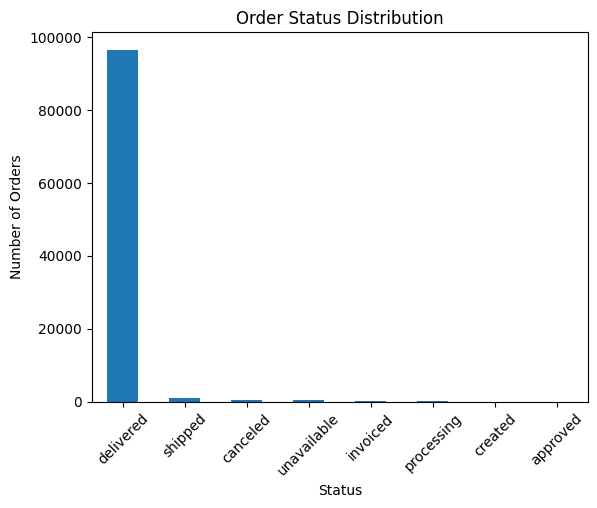

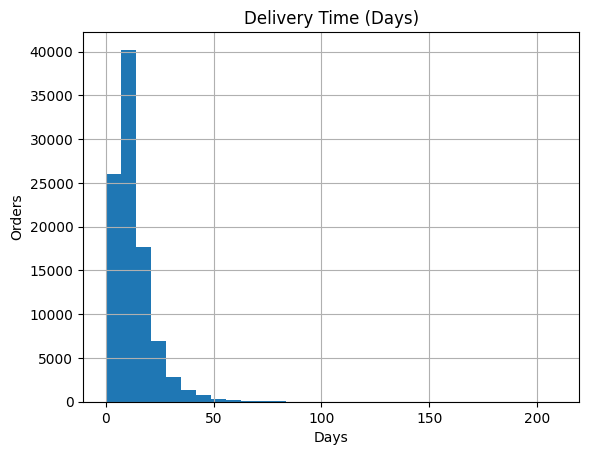

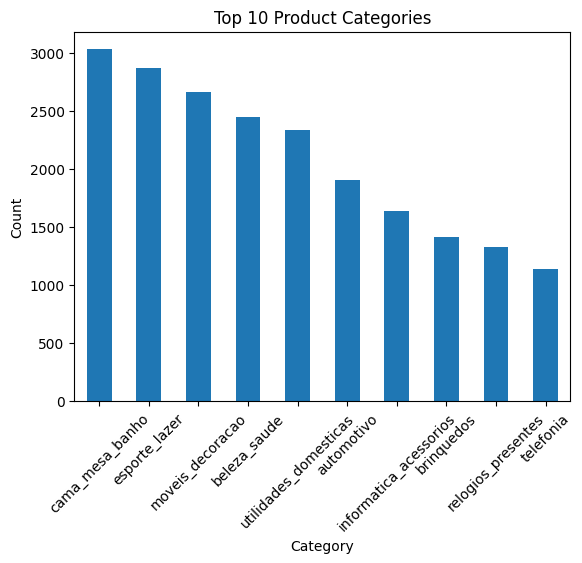

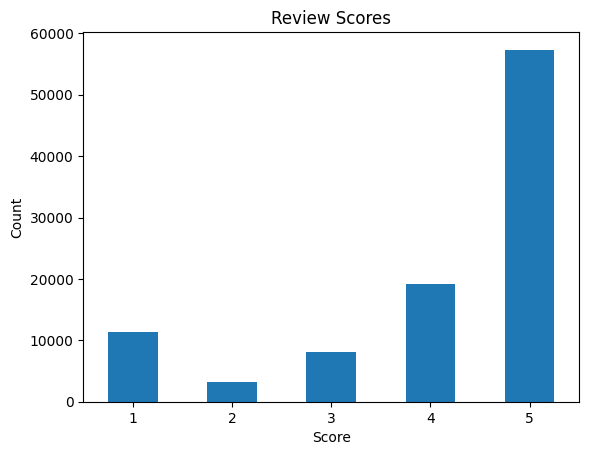

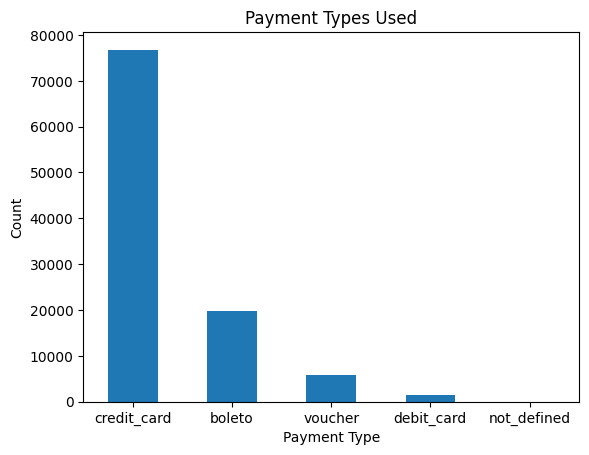

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import io
from google.colab import files
import zipfile

uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]
with zipfile.ZipFile(io.BytesIO(uploaded[zip_filename]), 'r') as zip_ref:
    zip_ref.extractall('.')

# Load datasets using extracted files
orders = pd.read_csv('olist_orders_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')

# Convert date columns to datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

# 1. Order Status Distribution
orders['order_status'].value_counts().plot(kind='bar', title='Order Status Distribution')
plt.xlabel('Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

# 2. Delivery Time Histogram
orders['delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days
orders['delivery_days'].dropna().hist(bins=30)
plt.title('Delivery Time (Days)')
plt.xlabel('Days')
plt.ylabel('Orders')
plt.show()

# 3. Top Product Categories
products['product_category_name'].value_counts().head(10).plot(kind='bar', title='Top 10 Product Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# 4. Review Score Distribution
reviews['review_score'].value_counts().sort_index().plot(kind='bar', title='Review Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# 5. Payment Type Breakdown
payments['payment_type'].value_counts().plot(kind='bar', title='Payment Types Used')
plt.xlabel('Payment Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

Key Insights:
**Order Status Distribution**
A bar chart was used to display the distribution of order statuses. The majority of orders were marked as “delivered,” with smaller but significant counts for “canceled” and “pending” orders. These variations support the feasibility of classification modeling.

**Delivery Time Analysis**
Delivery time was calculated as the number of days between the purchase date and the delivery date. A histogram showed that most orders were delivered within 20 days, although some outliers with longer delivery periods were observed.

**Product Category Frequency**
A bar chart of the top 10 product categories revealed that “bed_bath_table” and “health_beauty” were among the most frequently ordered. This provides insight into consumer preferences on the platform.

**Review Score Distribution**
Review scores ranged from 1 to 5, with the majority clustered around 4 and 5 stars. However, a notable number of low scores highlighted the potential for exploring drivers of customer dissatisfaction.

**Payment Method Breakdown**
The majority of customers used credit cards, followed by boleto, vouchers, and debit cards. These insights may help identify which payment methods are linked to higher completion or satisfaction rates.

**Observations:**
Some missing values were identified in timestamp fields and delivery dates.
The dataset’s richness across categories enables multi-dimensional analysis, such as linking review scores to product types or delivery times.
The structure, which includes one-to-many relationships between customers and orders or orders and items, supports more advanced modeling and aggregation techniques.





**Data Cleaning and Preprocessing**
1. Handling Missing Values: Some timestamp fields had null values, particularly in canceled or unshipped orders. These were either filled or dropped depending on the business context.

Rationale: A missing delivery date for a "delivered" order indicates bad data. These rows were removed to ensure accuracy in modeling delivery performance



In [3]:
# Drop orders with missing delivery dates if 'order_status' is 'delivered'
orders_clean = orders[~((orders['order_status'] == 'delivered') & (orders['order_delivered_customer_date'].isnull()))]

2. Feature Engineering: Delivery Time & Delay
To predict order outcomes or customer satisfaction, we engineered a new feature: delivery time in days.
Rationale: Delivery time is a meaningful continuous variable that can impact both customer satisfaction and order status.


In [ ]:
orders_clean['order_purchase_timestamp'] = pd.to_datetime(orders_clean['order_purchase_timestamp'])
orders_clean['order_delivered_customer_date'] = pd.to_datetime(orders_clean['order_delivered_customer_date'])
orders_clean['delivery_days'] = (orders_clean['order_delivered_customer_date'] - orders_clean['order_purchase_timestamp']).dt.days

3. Categorical Encoding
Several columns such as payment method, product category, and order status are categorical. Label encoding or one-hot encoding was applied depending on modeling needs
Rationale: Label encoding simplifies categorical variables for models like logistic regression. One-hot encoding could be used for tree-based models.

In [6]:
from sklearn.preprocessing import LabelEncoder

label_cols = ['payment_type', 'payment_sequential', 'payment_installments']

le = LabelEncoder()
for col in label_cols:
    payments[col] = le.fit_transform(payments[col]) # Apply label encoding

4. Merging Tables for Modeling
To enrich the feature set, relevant tables were merged based on order_id.
Rationale: Combining customer reviews, payment data, and delivery performance offers a more holistic dataset for classification or regression models.

In [7]:
df = orders_clean.merge(reviews, on='order_id', how='left')
df = df.merge(payments, on='order_id', how='left')

5. Train/Test Split and Scaling
The final dataset was split and scaled for modeling.
Rationale: Scaling ensures better performance for models sensitive to feature magnitude (e.g., logistic regression or SVM).

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = df[['delivery_days', 'payment_type']]
target = df['review_score']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Formulating Business Analytics Questions**
1. Which product categories tend to have the longest delivery times?
This helps the logistics and inventory teams identify product types that may need better fulfillment planning or stocking strategies to reduce delays.

2. Do certain sellers consistently receive higher review scores than others?
Analyzing seller performance can support marketplace quality control and inform partnership strategies by identifying top-performing or underperforming vendors.

3. Is there a relationship between the number of items in an order and customer satisfaction?
This insight could be valuable for user experience teams, helping them understand if larger orders lead to more issues or longer delivery times, and how that impacts customer feedback.

**Predictive Modeling**
1. Which product categories tend to have the longest delivery times?

Modeling Goal: Predict delivery time
Models Used: Linear Regression, Random Forest Regressor (for non-linear relationships)
Target Variable: delivery_days
Features: product_category_encoded, num_items

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Merge product info to include category
order_items = pd.read_csv('olist_order_items_dataset.csv')
order_items = order_items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')

# Merge with delivery time info
delivery_df = order_items.merge(orders_clean[['order_id', 'delivery_days']], on='order_id', how='left')

# Encode product category
le = LabelEncoder()
delivery_df['product_category_encoded'] = le.fit_transform(delivery_df['product_category_name'].astype(str))

# Count items per order
item_counts = order_items.groupby('order_id')['order_item_id'].count().reset_index()
item_counts.columns = ['order_id', 'num_items']
delivery_df = delivery_df.merge(item_counts, on='order_id', how='left')

# Drop nulls
delivery_df = delivery_df.dropna(subset=['delivery_days'])

# Define features and target
X1 = delivery_df[['product_category_encoded', 'num_items']]
y1 = delivery_df['delivery_days']
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=1)

# Linear Regression
lr1 = LinearRegression().fit(X1_train, y1_train)
lr1_preds = lr1.predict(X1_test)

# Random Forest
rf1 = RandomForestRegressor(random_state=1).fit(X1_train, y1_train)
rf1_preds = rf1.predict(X1_test)

# Scores
lr1_rmse = np.sqrt(mean_squared_error(y1_test, lr1_preds))
rf1_rmse = np.sqrt(mean_squared_error(y1_test, rf1_preds))


2. Do certain sellers consistently receive higher review scores than others?

Modeling Goal: Predict review score
Models Used: Decision Tree Regressor or Classifier, Random Forest Regressor or Classifier
Target Variable: review_score
Features: seller_id, delivery_days, num_items

In [10]:
# Load seller info
order_items = order_items.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')
seller_df = order_items.merge(orders_clean[['order_id', 'delivery_days']], on='order_id', how='left')
seller_df['seller_id_encoded'] = le.fit_transform(seller_df['seller_id'].astype(str))

# Drop nulls
seller_df = seller_df.dropna(subset=['review_score', 'delivery_days'])

# Features and target
X2 = seller_df[['seller_id_encoded', 'delivery_days', 'order_item_id']]
y2 = seller_df['review_score']
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=1)

# Linear Regression
lr2 = LinearRegression().fit(X2_train, y2_train)
lr2_preds = lr2.predict(X2_test)

# Random Forest
rf2 = RandomForestRegressor(random_state=1).fit(X2_train, y2_train)
rf2_preds = rf2.predict(X2_test)

# Scores
lr2_rmse = np.sqrt(mean_squared_error(y2_test, lr2_preds))
rf2_rmse = np.sqrt(mean_squared_error(y2_test, rf2_preds))

3. Is there a relationship between the number of items in an order and customer satisfaction?

Modeling Goal: Predict review score based on order size
Models Used: Linear Regression or Logistic Regression, Random Forest Classifier
Target Variable: review_score (or review_score >= 4 as binary)
Features: num_items, delivery_days, maybe product_category_encoded

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

satisfaction_df = seller_df.copy()
satisfaction_df['high_satisfaction'] = (satisfaction_df['review_score'] >= 4).astype(int)

X3 = satisfaction_df[['order_item_id', 'delivery_days']]
y3 = satisfaction_df['high_satisfaction']
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=1)

# Logistic Regression
logreg3 = LogisticRegression().fit(X3_train, y3_train)
logreg_preds = logreg3.predict(X3_test)

# Random Forest Classifier
rf3 = RandomForestClassifier(random_state=1).fit(X3_train, y3_train)
rf3_preds = rf3.predict(X3_test)

# Accuracy scores
logreg_acc = accuracy_score(y3_test, logreg_preds)
rf3_acc = accuracy_score(y3_test, rf3_preds)

Performance Table

In [25]:
performance_table = pd.DataFrame({
    'Business Question': [
        'Predict Delivery Days',
        'Predict Delivery Days',
        'Predict Review Score by Seller',
        'Predict Review Score by Seller',
        'Classify High Satisfaction',
        'Classify High Satisfaction'
    ],
    'Model': [
        'Linear Regression',
        'Random Forest Regressor',
        'Linear Regression',
        'Random Forest Regressor',
        'Logistic Regression',
        'Random Forest Classifier'
    ],
    'Metric': [
        'RMSE', 'RMSE', 'RMSE', 'RMSE', 'Accuracy', 'Accuracy'
    ],
    'Score': [
        lr1_rmse, rf1_rmse, lr2_rmse, rf2_rmse, logreg_acc, rf3_acc
    ]
})

performance_table

,Business Question,Model,Metric,Score
0,Predict Delivery Days,Linear Regression,RMSE,9.060754
1,Predict Delivery Days,Random Forest Regressor,RMSE,8.951701
2,Predict Review Score by Seller,Linear Regression,RMSE,1.263263
3,Predict Review Score by Seller,Random Forest Regressor,RMSE,1.340847
4,Classify High Satisfaction,Logistic Regression,Accuracy,0.791937
5,Classify High Satisfaction,Random Forest Classifier,Accuracy,0.792256
